In [19]:
import math # exp/tanh
import numpy as np # arange for plotting f(x)
import torch
import random # random initial weights and biases
import matplotlib.pyplot as plt
%matplotlib inline

In [20]:
# toy function f(x) = 3x^2 - 4x + 5, used to build intuition for derivatives
def f(x):
    return 3*x**2 - 4*x + 5

In [21]:
f(3.0) # 3*9 - 12 + 5 = 20

20.0

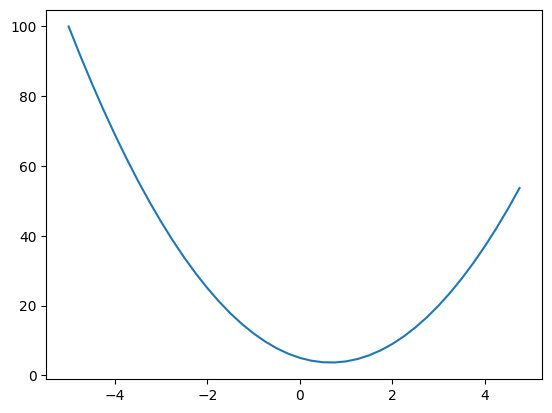

In [22]:
# plot f over [-5, 5) in steps of 0.25
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [23]:
# a scalar that remembers how it was computed, so gradients can flow backward through the graph
class Value:
    def __init__(self, data, _children=(), _op='', label = ''):
        self.data = data # the number this node holds
        self.grad = 0.0 # d(final output)/d(this node); stays 0 until backward() runs
        self._prev = set(_children) # the nodes this one was computed from
        self._backward = lambda: None # leaf nodes have nothing to propagate
        self._op = _op # operation that produced this node (used when drawing the graph)
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) #to allow quick mathematical calculations of object and other data type such as int or float
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward(): # + passes the upstream grad to both inputs (local derivative = 1)
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
            
        out._backward = _backward
        
        return out

    def __radd__(self, other):
        return self + other

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) #to allow quick mathematical calculations of object and other data type such as int or float
        out = Value(self.data * other.data, (self, other), '*')

        def _backward(): # chain rule: d(a*b)/da = b and d(a*b)/db = a, each times the upstream grad
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
            
        out._backward = _backward

        return out
        
    def __rmul__(self, other): # other * self
        return self * other


    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward(): # power rule: d(x^k)/dx = k * x^(k-1)
            self.grad += other * (self.data**(other - 1)) * out.grad

        out._backward = _backward

        return out


    def __rsub__(self, other): # other - self
        return other + (-self)

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

        
    def tanh(self):
        x = self.data
        t = math.tanh(x) # same as (e^2x - 1)/(e^2x + 1), but doesn't overflow for large |x|
        out = Value(t, (self, ), 'tanh')

        def _backward(): # d(tanh x)/dx = 1 - tanh(x)^2
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward
        
        return out

    def exp(self):
        x = self.data
        out  = Value(math.exp(x), (self, ), 'exp')

        def _backward(): # d(e^x)/dx = e^x
            self.grad += out.data * out.grad

        out._backward = _backward

        return out

    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v) #reach the leaves first, then start adding their nodes one by one to topo

        build_topo(self)

        self.grad = 1.0 # d(out)/d(out) = 1, the starting point of backprop
        for node in reversed(topo): # from the output back to the leaves
            node._backward()
                

a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
a + b #python internally calls a.__add__(b)
a * b #python internally calls a.__mul__(b)
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f_ = Value(-2.0, label = 'f')
L = d * f_; L.label = 'L'
#set out because, when using graph set outputs at O(1) time when used for checking if something exists or not.


In [24]:
from graphviz import Digraph
from collections import deque

#DFS
def trace(root):
    # build a set of all nodes and edges in a graph  
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges


#BFS
'''def trace(root):
    # build a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    queue = deque([root]) #line begins here
    nodes.add(root) #mark root as already in the system; in case it has two reachable paths, it will be added twice to the nodes
    
    while queue:
        v = queue.popleft() #remove from the front 
        for child in v._prev:
            edges.add((child, v)) #add (child, v) pair in nodes
            if child not in nodes: #if child is not in nodes, then add it and append it to the back of the line 
                nodes.add(child)
                queue.append(child) #enqueue - add to the back of the line 
    return nodes, edges'''
    
def draw_dot(root):
    dot = Digraph(format='svg', graph_attr = {'rankdir': 'LR'}) #LR is left to right, and this creates an empty graph with direction left to right

    nodes, edges = trace(root)

    for n in nodes: #create rectangles and ovals for value objects and ops respectively
        uid = str(id(n))
        #for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad  ), shape = 'record')
        if n._op:
            #if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            #and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        #connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


In [25]:
#inputs x1, x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

#weights w1, w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

#bias of the neuron
b = Value(6.8813735870195432, label = 'b')

#x1w1 + x2w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1 * w1'
x2w2 = x2 * w2; x2w2.label = 'x2 * w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'

n = x1w1x2w2 + b; n.label = 'n'

# tanh built by hand from exp, so backprop has to go through each small op
e = (2*n).exp()
o = (e - 1) / (e + 1) ; o.label = 'o'



In [26]:
#manual backprop

'''o.grad = 1.0
n.grad = 0.5 # do / dn = 1 - o**2
x1w1x2w2.grad = 0.5
b.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad'''

'o.grad = 1.0\nn.grad = 0.5 # do / dn = 1 - o**2\nx1w1x2w2.grad = 0.5\nb.grad = 0.5\nx1w1.grad = 0.5\nx2w2.grad = 0.5\nx2.grad = w2.data * x2w2.grad\nw2.grad = x2.data * x2w2.grad\nx1.grad = w1.data * x1w1.grad\nw1.grad = x1.data * x1w1.grad'

In [27]:
# grads accumulate (+=): re-run the cell that builds the graph (x1, x2, w1, ... o) before re-running this
o.backward()

In [28]:
# o = tanh(n)
# do / dn = 1 - o**2

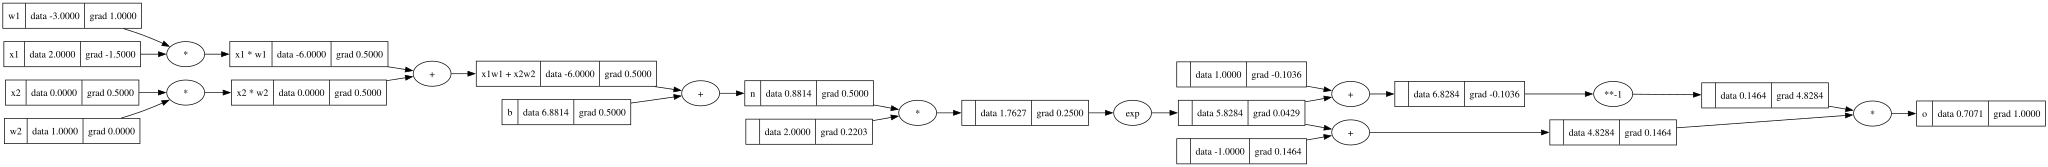

In [29]:
# draw the graph for o; every node shows its data and grad
draw_dot(o)


In [30]:
# one neuron computes tanh(w . x + b)
class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)] #for nin xi, randomly pick wi 
        self.b = Value(random.uniform(-1,1)) #for nin xi, randomly choose one bias

    def __call__(self, x):
        #w * x + b
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b) #zip lines up wi with xi, and wi * xi for runs a for loop and multiplies them which is added up and then summed with b just once.
        out = act.tanh() # squash the weighted sum into (-1, 1)
        return out

    def parameters(self):
        return self.w + [self.b]

# a layer is a list of neurons that all see the same inputs
class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)] #to generate weights and biases

    def __call__(self, x):
        outs = [n(x) for n in self.neurons] #to do the computation
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        #return [p for neuron in self.neurons for p in neuron.parameters()]
        params = []
        for neurons in self.neurons:
            ps = neurons.parameters()
            params.extend(ps)
        return params

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))] #creates a list lets say nin = [3] and nouts = [4,4,1] so the number of features are 3 and number of neurons per layer is 4, 4, 1 respectively and there are 3 layers in total defined by len (nouts); hence, we get 3 weights per neuron times 4 in the first layer, which equals 12. Then 4 inputs to 4 neurons: we get 1 per neuron, hence 16 in total, and then 4 in 1 neuron, hence 4 outputs. Total is 32. And 9 biases
        #in a loop first 3,4 nin and nouts, then it goes on.
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x); #pass the input x to layers one by one, which does parallel computing across one layer 
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        

In [31]:
# 3 inputs -> 4 -> 4 -> 1 output, 41 parameters (32 weights + 9 biases)
# create this once: re-running it throws the trained weights away and starts from new random ones
n = MLP(3, [4, 4, 1])

In [32]:

# 4 training examples, 3 input features each
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, 1.0],
]

ys = [1.0, -1.0, -1.0, 1.0] #desired output

# forward pass: run every example through the network
ypred = [n(x) for x in xs]
ypred



[Value(data=-0.0017884662052016773),
 Value(data=-0.876435627367936),
 Value(data=-0.3933771459594048),
 Value(data=-0.485313104379108)]

In [37]:
# gradient descent, lr = 0.05: forward -> zero grads -> backward -> update, repeated 50 times
for k in range(50):

    #forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    #backward pass
    for p in n.parameters():
        p.grad = 0.0 # backward() adds to .grad with +=, so clear the old grads first
    loss.backward()

    #update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)

        


0 4.767734731605948
1 3.9934188103462565
2 3.985135821804509
3 3.978039757824481
4 3.971560050374286
5 3.965317595753545
6 3.95902250380622
7 3.952417579231366
8 3.945239269085865
9 3.9371818227540643
10 3.927853985814647
11 3.916715251879885
12 3.9029695751034446
13 3.885371838031503
14 3.861846511193919
15 3.82866953863879
16 3.7785278840144625
17 3.695319574697282
18 3.5380702640354604
19 3.1848634847257475
20 2.302428261077377
21 1.4285375583709852
22 1.3305848620582417
23 1.2275619261329274
24 1.120052079015962
25 1.0110789831203548
26 0.9056428447515046
27 0.8111930208168856
28 0.7455735175822104
29 0.758552731509994
30 0.9883547034483695
31 1.7479664152598016
32 1.8435064197038409
33 2.1346066323079276
34 1.0044375433403494
35 1.4195877431768977
36 1.6892545184515428
37 1.865375941336532
38 1.155229054505191
39 1.3243548846644821
40 1.4348219038512215
41 1.5274762792957017
42 1.2898975486263158
43 1.2480734745600282
44 1.2175008032886991
45 1.0922783425925358
46 1.04819778541295

In [34]:
# manual version of the loop above, one step at a time.
# re-run the forward-pass cell (ypred) first, then this cell, then the update cell below
# squared-error loss: sum over the 4 examples of (prediction - target)^2
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=2.0473984573881787)

In [35]:
# one gradient-descent step (lr = 0.01). Run the forward pass and loss cells before every step,
# otherwise backward() runs on a stale graph and the update uses wrong gradients.
loss.backward()

for p in n.parameters():
    p.data += -0.01 * p.grad # step against the gradient
    p.grad = 0 # reset so grads don't pile up into the next step

In [36]:
# first weight of the first neuron in layer 0, handy for watching a parameter change
n.layers[0].neurons[0].w[0].data

-0.32211837455382786